In [1]:
import os

os.listdir("../data/raw")

['PRSA2017_Data_20130301-20170228.zip']

In [2]:
import zipfile
import pandas as pd

zip_path = "../data/raw/PRSA2017_Data_20130301-20170228.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

files[:5]

['PRSA_Data_20130301-20170228/',
 'PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv']

In [3]:
dfs = []

with zipfile.ZipFile(zip_path, "r") as z:
    for file in z.namelist():
        if file.endswith(".csv"):
            df_station = pd.read_csv(z.open(file))
            df_station["station"] = file.replace(".csv", "")
            dfs.append(df_station)

df = pd.concat(dfs, ignore_index=True)
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,PRSA_Data_20130301-20170228/PRSA_Data_Aotizhon...
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,PRSA_Data_20130301-20170228/PRSA_Data_Aotizhon...
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,PRSA_Data_20130301-20170228/PRSA_Data_Aotizhon...
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,PRSA_Data_20130301-20170228/PRSA_Data_Aotizhon...
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,PRSA_Data_20130301-20170228/PRSA_Data_Aotizhon...


In [4]:
df["datetime"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]]
)

df = df.sort_values("datetime")
df.set_index("datetime", inplace=True)

df[["PM2.5"]].head()

,PM2.5
datetime,
2013-03-01,4.0
2013-03-01,6.0
2013-03-01,4.0
2013-03-01,8.0
2013-03-01,3.0


## 1. Plot PM2.5 over Time

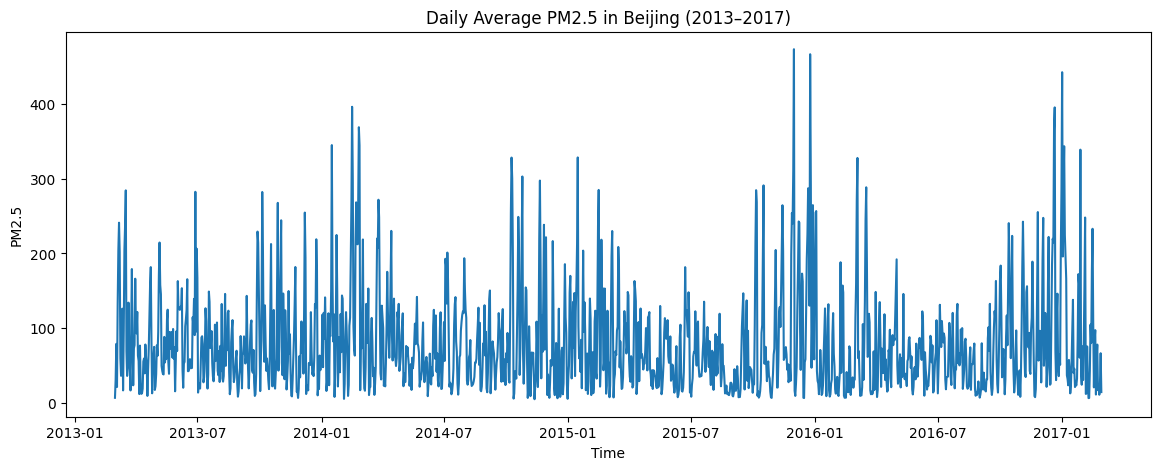

In [5]:
pm25_ts = df["PM2.5"].resample("D").mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(pm25_ts)
plt.title("Daily Average PM2.5 in Beijing (2013–2017)")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.show()

## 2. Missing Value Handling

In [7]:
pm25_ts.isna().sum()
pm25_ts_filled = pm25_ts.interpolate(method="time")

## 3. Trend and Seasonality Analysis

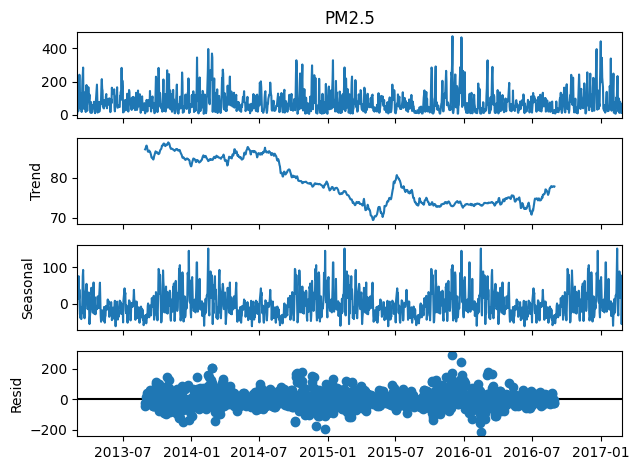

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(pm25_ts_filled, model="additive", period=365)
decomp.plot()
plt.show()

## 4. Time Series Forecasting with ARIMA


In [9]:
pm25_ts = df["PM2.5"].resample("D").mean()
pm25_ts = pm25_ts.interpolate(method="time")

pm25_ts.head()

datetime
2013-03-01      7.326389
2013-03-02     31.475694
2013-03-03     79.291667
2013-03-04     21.731449
2013-03-05    132.439114
Freq: D, Name: PM2.5, dtype: float64

In [10]:
train = pm25_ts[:'2016-12-31']
test  = pm25_ts['2017-01-01':]

print("Train size:", train.shape)
print("Test size:", test.shape)

Train size: (1402,)
Test size: (59,)


In [11]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1402
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7583.277
Date:                Wed, 07 Jan 2026   AIC                          15172.553
Time:                        00:22:48   BIC                          15188.288
Sample:                    03-01-2013   HQIC                         15178.435
                         - 12-31-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5738      0.013     44.720      0.000       0.549       0.599
ma.L1         -0.9997      0.010   -101.107      0.000      -1.019      -0.980
sigma2      2932.6813     79.412     36.930      0.0

In [12]:
forecast = model_fit.forecast(steps=len(test))
forecast.head()

2017-01-01    197.946055
2017-01-02    147.396036
2017-01-03    118.392288
2017-01-04    101.751000
2017-01-05     92.202838
Freq: D, Name: predicted_mean, dtype: float64

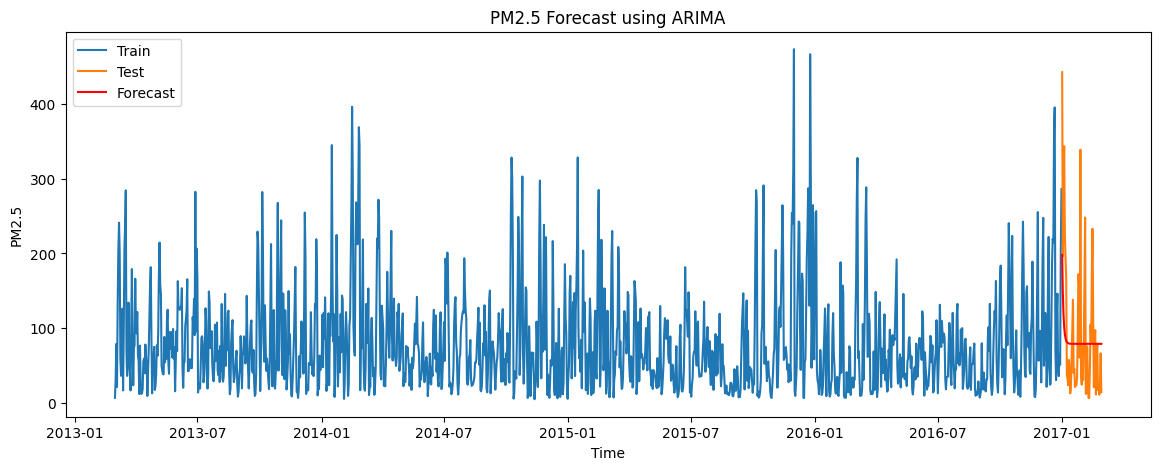

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Forecast", color="red")
plt.legend()
plt.title("PM2.5 Forecast using ARIMA")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.show()

# Nhận xét kết quả phân tích chuỗi thời gian PM2.5 (2013–2017)

## 1. Biến động PM2.5 theo thời gian
Biểu đồ PM2.5 theo thời gian cho thấy nồng độ bụi mịn biến động rất mạnh trong toàn bộ giai đoạn nghiên cứu. Nhiều thời điểm xuất hiện các đỉnh PM2.5 cao bất thường, có giá trị vượt trên 300–400, phản ánh các đợt ô nhiễm nghiêm trọng. Ngược lại, vào một số giai đoạn, đặc biệt là giữa năm, mức PM2.5 thấp và ổn định hơn, cho thấy dữ liệu có tính chu kỳ theo mùa rõ rệt.

## 2. Xử lý giá trị thiếu
Sau khi nội suy các giá trị PM2.5 bị thiếu theo thời gian, chuỗi dữ liệu trở nên liên tục và mượt hơn. Việc xử lý này không làm thay đổi đáng kể cấu trúc dữ liệu ban đầu, các đỉnh và đáy vẫn được giữ lại, cho thấy phương pháp nội suy phù hợp với bài toán chuỗi thời gian.

## 3. Xu hướng (Trend)
Thành phần xu hướng cho thấy nồng độ PM2.5 trung bình có xu hướng giảm dần theo thời gian, đặc biệt từ sau năm 2015. Điều này cho thấy chất lượng không khí tại Bắc Kinh có dấu hiệu được cải thiện trong giai đoạn cuối của tập dữ liệu.

## 4. Tính mùa vụ (Seasonality)
Biểu đồ mùa vụ thể hiện rõ chu kỳ lặp lại hàng năm của PM2.5. Mức độ ô nhiễm thường tăng cao vào mùa đông và giảm vào mùa hè. Kết quả này phù hợp với thực tế khi mùa đông có hoạt động sưởi ấm nhiều hơn và điều kiện khí tượng kém thuận lợi cho việc khuếch tán không khí ô nhiễm.

## 5. Nhiễu (Residual)
Phần dư dao động quanh giá trị 0 và không có xu hướng rõ ràng, cho thấy việc phân tách xu hướng và mùa vụ là tương đối hiệu quả. Tuy nhiên, vẫn tồn tại một số điểm nhiễu lớn, phản ánh các biến động đột ngột do các yếu tố bất thường như thời tiết cực đoan hoặc hoạt động của con người.

## 6. Dự báo bằng mô hình ARIMA
Kết quả dự báo bằng mô hình ARIMA cho thấy mô hình bám sát xu hướng chung của dữ liệu PM2.5 trong giai đoạn kiểm tra. Tuy nhiên, đường dự báo có xu hướng mượt hơn so với dữ liệu thực tế và không phản ánh được các đỉnh ô nhiễm tăng đột ngột. Điều này cho thấy ARIMA phù hợp cho dự báo xu hướng dài hạn nhưng còn hạn chế trong việc dự báo các biến động mạnh trong ngắn hạn.

## 7. Kết luận
Dựa trên các biểu đồ và kết quả phân tích, dữ liệu PM2.5 mang đầy đủ đặc trưng của chuỗi thời gian bao gồm xu hướng dài hạn, tính mùa vụ rõ ràng và nhiễu ngẫu nhiên. Mô hình ARIMA cho kết quả dự báo hợp lý ở mức xu hướng tổng thể, tuy nhiên để nâng cao độ chính xác trong thực tế, có thể cần kết hợp thêm các biến ngoại sinh hoặc các mô hình dự báo nâng cao hơn.
